# Notebook 07 — MP2 & Harmonic Vibrational Frequencies

**MOLEKUL | Phases 8 & 10**

---

Hartree-Fock misses **electron correlation** — the correlated motion that keeps
electrons from occupying the same space simultaneously. The result is a systematic
overestimation of bond lengths and reaction barriers.

**MP2** (Møller-Plesset second-order perturbation theory) is the simplest post-HF
correction. It adds the dominant correlation energy in one analytically tractable step.

**Harmonic frequencies** — computed from the curvature of the PES — tell us about
molecular vibrations, zero-point energy, and which structures are true minima (no
imaginary frequencies) vs. transition states (one imaginary frequency).

**What you will learn:**
1. The MP2 energy formula and the AO→MO integral transformation.
2. Why MP2 scales as $\mathcal{O}(N^5)$ and when it is reliable.
3. The numerical Hessian and mass-weighted normal mode analysis.
4. Zero-point energy, IR intensities, and the double-harmonic approximation.
5. What imaginary frequencies mean and how to detect them.

## 1. MP2 theory

### Perturbation expansion

Partition the Hamiltonian as $\hat{H} = \hat{H}_0 + \hat{V}$, where $\hat{H}_0$
is the Fock operator and $\hat{V}$ is the electron-electron repulsion minus the
HF mean field. The second-order energy correction is:

$$E_{\text{MP2}} = \sum_{i<j}\sum_{a<b}
\frac{|\langle ij||ab \rangle|^2}{\varepsilon_i + \varepsilon_j - \varepsilon_a - \varepsilon_b}$$

In the closed-shell (RHF) spin-summed form with chemists' two-electron integrals:

$$E_{\text{MP2}} = \sum_{i,j}\sum_{a,b}
\frac{(ia|jb)\left[2(ia|jb) - (ib|ja)\right]}
{\varepsilon_i + \varepsilon_j - \varepsilon_a - \varepsilon_b}$$

where $i,j$ are **occupied** MO indices and $a,b$ are **virtual** MO indices.

**Key features:**
- Denominator is always negative (stable HF reference) → $E_{\text{MP2}} < 0$ (correlation energy lowers energy).
- Numerator: the correlation part of the two-electron repulsion.
- Requires integrals in the **MO basis**: $(ia|jb) = \sum_{\mu\nu\lambda\sigma} C_{\mu i}C_{\nu a} (\mu\nu|\lambda\sigma) C_{\lambda j}C_{\sigma b}$.

### Scaling

The AO→MO transformation has four steps, each $\mathcal{O}(N^5)$:
$$\text{AO} \xrightarrow{C_{\mu i}} \xrightarrow{C_{\nu a}} \xrightarrow{C_{\lambda j}} \xrightarrow{C_{\sigma b}} (ia|jb)$$

MP2 scales as $\mathcal{O}(N^5)$ vs. $\mathcal{O}(N^4)$ for HF — feasible up to
~100 basis functions in memory with in-core full storage.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.basis_ccpvdz import ccpVDZ
from molekul.rhf import rhf_scf
from molekul.mp2 import mp2_energy, transform_iajb
from molekul.freqs import harmonic_analysis, FREQ_CONV
from molekul.eri import build_eri
from molekul.constants import HARTREE_TO_KCAL_MOL, HARTREE_TO_EV

h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)
print("Ready.")

Ready.


In [2]:
basis = STO3G

# Step 1: RHF reference
rhf_res = rhf_scf(h2o, basis)
print(f"RHF energy:  {rhf_res.energy_total:.8f} Ha")

# Step 2: MP2 correction
mp2_res = mp2_energy(h2o, basis, rhf_res)
print(f"MP2 corr.:   {mp2_res.energy_mp2:.8f} Ha")
print(f"MP2 total:   {mp2_res.energy_total:.8f} Ha")
print(f"MP2 corr. = {mp2_res.energy_mp2 * HARTREE_TO_KCAL_MOL:.2f} kcal/mol")
print(f"           = {mp2_res.energy_mp2 * HARTREE_TO_EV:.4f} eV")

RHF energy:  -74.96302315 Ha


MP2 corr.:   -0.03554565 Ha
MP2 total:   -74.99856879 Ha
MP2 corr. = -22.31 kcal/mol
           = -0.9672 eV


## 2. The AO→MO integral transformation

The ERI tensor in the AO basis is $(\mu\nu|\lambda\sigma)$ — a rank-4 tensor.
MP2 needs the occupied-virtual block $(ia|jb)$ in the MO basis.

MOLEKUL does this with four sequential contractions (`np.einsum`):
```
1. tmp[i,ν,λ,σ]  = Σ_μ C_{μi} eri[μ,ν,λ,σ]    — first quarter
2. tmp[i,a,λ,σ]  = Σ_ν C_{νa} tmp[i,ν,λ,σ]    — second quarter
3. tmp[i,a,j,σ]  = Σ_λ C_{λj} tmp[i,a,λ,σ]    — third quarter
4. (ia|jb)       = Σ_σ C_{σb} tmp[i,a,j,σ]    — fourth quarter
```

Memory usage: for $n_o$ occupied and $n_v$ virtual orbitals, the result is
$n_o^2 n_v^2$ doubles — much smaller than the full AO tensor $n^4$.

In [3]:
nocc  = h2o.n_electrons // 2
C     = rhf_res.mo_coefficients
eri   = build_eri(basis, h2o)

iajb  = transform_iajb(eri, C, nocc)
nvirt = iajb.shape[1]

print(f"n_occ = {nocc}, n_virt = {nvirt}")
print(f"(ia|jb) block shape: {iajb.shape}  ({iajb.nbytes/1024:.1f} KB)")
print(f"Full AO ERI shape would be: {eri.shape}  ({eri.nbytes/1024:.1f} KB)")

n_occ = 5, n_virt = 2
(ia|jb) block shape: (5, 2, 5, 2)  (0.8 KB)
Full AO ERI shape would be: (7, 7, 7, 7)  (18.8 KB)


In [4]:
# Compute E_MP2 manually to verify
eps = rhf_res.mo_energies
eps_occ = eps[:nocc]
eps_vir = eps[nocc:]

E_mp2_manual = 0.0
for i in range(nocc):
    for a in range(nvirt):
        for j in range(nocc):
            for b in range(nvirt):
                num = iajb[i,a,j,b] * (2*iajb[i,a,j,b] - iajb[i,b,j,a])
                den = eps_occ[i] + eps_occ[j] - eps_vir[a] - eps_vir[b]
                E_mp2_manual += num / den

print(f"E_MP2 (manual):   {E_mp2_manual:.8f} Ha")
print(f"E_MP2 (module):   {mp2_res.energy_mp2:.8f} Ha")
print(f"Difference:       {abs(E_mp2_manual - mp2_res.energy_mp2):.2e} Ha")

E_MP2 (manual):   -0.03554565 Ha
E_MP2 (module):   -0.03554565 Ha
Difference:       0.00e+00 Ha


## 3. MP2 for several molecules

Let us see how the correlation energy varies across molecules, and how it compares
to PySCF reference values.

In [5]:
from molekul.mp2 import mp2_energy

molecules = {
    "H2":  Molecule(atoms=[Atom.from_angstrom("H", 0,0,0.37),
                           Atom.from_angstrom("H", 0,0,-0.37)]),
    "H2O": h2o,
    "N2":  Molecule(atoms=[Atom.from_angstrom("N", 0,0,0.549),
                           Atom.from_angstrom("N", 0,0,-0.549)]),
}

basis = STO3G
print(f"{'Mol':6s}  {'E_HF (Ha)':>14}  {'E_MP2 corr':>14}  {'E_MP2 total':>14}")
print("-" * 55)
for name, mol in molecules.items():
    rhf = rhf_scf(mol, basis)
    mp2 = mp2_energy(mol, basis, rhf)
    print(f"{name:6s}  {rhf.energy_total:>14.6f}  {mp2.energy_mp2:>14.6f}  {mp2.energy_total:>14.6f}")

Mol          E_HF (Ha)      E_MP2 corr     E_MP2 total
-------------------------------------------------------
H2           -1.116759       -0.013138       -1.129897


H2O         -74.963023       -0.035546      -74.998569


N2         -107.495975       -0.154199     -107.650174


## 4. Harmonic vibrational analysis

### The Hessian

At an energy minimum, the PES is locally quadratic:
$$E(\mathbf{R} + \mathbf{\Delta}) \approx E(\mathbf{R}_0) + \frac{1}{2}\mathbf{\Delta}^T \mathbf{H}\, \mathbf{\Delta}$$

The **Hessian** $H_{\alpha\beta} = \partial^2 E / \partial q_\alpha \partial q_\beta$
is computed by MOLEKUL using central finite differences ($3N^2 + \mathcal{O}(N)$ SCF calls).

### Mass-weighted normal modes

The classical equations of motion with the Hessian give normal mode frequencies.
The mass-weighted Hessian is:
$$\tilde{H}_{\alpha\beta} = \frac{H_{\alpha\beta}}{\sqrt{m_\alpha m_\beta}}$$

Diagonalising $\tilde{\mathbf{H}}\,\boldsymbol{\Phi} = \boldsymbol{\Phi}\,\boldsymbol{\Lambda}$ gives:
$$\omega_k = \text{sign}(\lambda_k)\sqrt{|\lambda_k|} \times \text{FREQ\_CONV}$$

FREQ_CONV $\approx 5140.5$ converts $\sqrt{E_h/(a_0^2 \cdot \text{amu})}$ to cm$^{-1}$.

A true minimum has all $\omega_k > 0$ (positive-definite Hessian).
A transition state has exactly one imaginary frequency ($\omega_k < 0$).

### Translation and rotation

Of the $3N$ modes, 6 are zero (3 translations + 3 rotations; 5 for linear molecules).
MOLEKUL identifies these automatically; only the $3N-6$ vibrational modes are reported.

In [6]:
# Harmonic analysis for H2O/STO-3G at experimental geometry
print("Running harmonic analysis for H₂O/STO-3G...")
freq_res = harmonic_analysis(h2o, STO3G)

print(f"\nVibrational frequencies:")
for i, (f, A) in enumerate(zip(freq_res.frequencies, freq_res.intensities)):
    print(f"  Mode {i+1}: {f:8.1f} cm⁻¹   IR intensity = {A:.1f} km/mol")

print(f"\nZero-point energy: {freq_res.zero_point_energy:.6f} Ha")
print(f"                 = {freq_res.zero_point_energy * HARTREE_TO_KCAL_MOL:.2f} kcal/mol")
print(f"\nImaginary modes: {freq_res.n_imaginary}")
print(f"Near-zero (t+r): {freq_res.n_zero}")

Running harmonic analysis for H₂O/STO-3G...
  Step 1/3: Numerical Hessian
  Hessian: 9 DOF, 163 SCF evaluations  (h = 5e-03 bohr)



  Step 2/3: Normal mode analysis
  Step 3/3: Dipole derivatives for IR intensities



  3-atom molecule, 9 DOF, 6 zero modes, 3 vibrations
  Imaginary frequencies: 0
  ZPE = 0.025793 Ha = 5660.9 cm⁻¹

Vibrational frequencies:
  Mode 1:   2043.1 cm⁻¹   IR intensity = 11.4 km/mol
  Mode 2:   4488.2 cm⁻¹   IR intensity = 37.4 km/mol
  Mode 3:   4790.6 cm⁻¹   IR intensity = 20.6 km/mol

Zero-point energy: 0.025793 Ha
                 = 16.19 kcal/mol

Imaginary modes: 0
Near-zero (t+r): 6


In [7]:
# Compare to experimental (gas-phase) fundamentals
exp_freqs = [1595, 3657, 3756]  # cm^-1 (symmetric bend, sym stretch, asym stretch)
print("H₂O vibrational frequencies:")
print(f"{'Mode':5s}  {'MOLEKUL':>12}  {'Experiment':>12}  {'Error':>10}")
for i, (f, fexp) in enumerate(zip(sorted(freq_res.frequencies), exp_freqs)):
    print(f"{i+1:5d}  {f:>12.1f}  {fexp:>12.1f}  {f-fexp:>+10.1f} cm⁻¹")
print("\nSTO-3G systematically overestimates stretch frequencies (~10-20%)")

H₂O vibrational frequencies:
Mode        MOLEKUL    Experiment       Error
    1        2043.1        1595.0      +448.1 cm⁻¹
    2        4488.2        3657.0      +831.2 cm⁻¹
    3        4790.6        3756.0     +1034.6 cm⁻¹

STO-3G systematically overestimates stretch frequencies (~10-20%)


## 5. IR spectrum simulation

The IR intensity is computed in the **double-harmonic approximation**:
$$A_k = \text{INTENS\_CONV}\sum_c\left|\frac{d\mu_c}{dQ_k}\right|^2$$

where $dQ_k$ is the normal coordinate and $d\mu_c/dQ_k$ is the dipole derivative
computed by finite differences.

We simulate the spectrum by broadening each line with a Lorentzian.

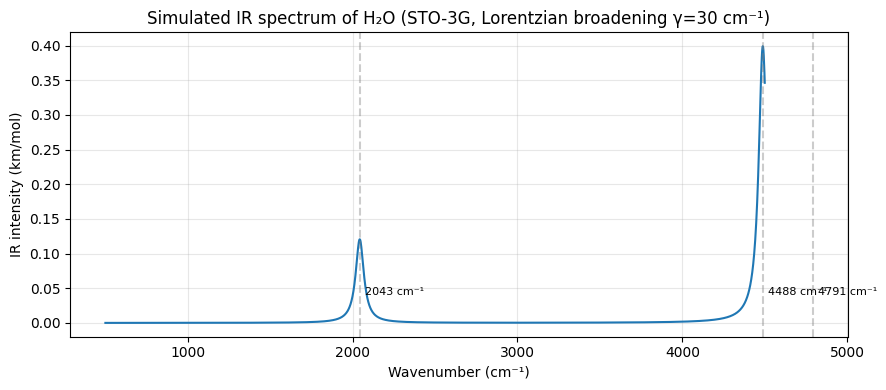

In [8]:
freq_range = np.linspace(500, 4500, 2000)
gamma = 30.0  # Lorentzian half-width (cm^-1)

spectrum = np.zeros_like(freq_range)
for f, A in zip(freq_res.frequencies, freq_res.intensities):
    spectrum += A * (gamma / np.pi) / ((freq_range - f)**2 + gamma**2)

plt.figure(figsize=(9, 4))
plt.plot(freq_range, spectrum)
for f, A in zip(freq_res.frequencies, freq_res.intensities):
    plt.axvline(f, ls="--", alpha=0.4, color="gray")
    plt.annotate(f"{f:.0f} cm⁻¹", xy=(f, 0), xytext=(f+30, spectrum.max()*0.1),
                 fontsize=8, ha="left")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("IR intensity (km/mol)")
plt.title("Simulated IR spectrum of H₂O (STO-3G, Lorentzian broadening γ=30 cm⁻¹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# H2 has only one vibrational mode (diatomic)
h2 = Molecule(
    atoms=[Atom.from_angstrom("H", 0, 0, 0.37),
           Atom.from_angstrom("H", 0, 0, -0.37)]
)
freq_h2 = harmonic_analysis(h2, STO3G, verbose=False)
print("H₂/STO-3G:")
print(f"  ν(H-H) = {freq_h2.frequencies[0]:.1f} cm⁻¹   (exp. 4161 cm⁻¹)")
print(f"  ZPE    = {freq_h2.zero_point_energy*HARTREE_TO_KCAL_MOL:.2f} kcal/mol")
print(f"  IR intensity = {freq_h2.intensities[0]:.3f} km/mol  (expected ~0 for homonuclear)")

H₂/STO-3G:
  ν(H-H) = 5040.2 cm⁻¹   (exp. 4161 cm⁻¹)
  ZPE    = 7.21 kcal/mol
  IR intensity = 0.000 km/mol  (expected ~0 for homonuclear)


---

## Exercises

**1.** Compute the MP2/STO-3G correlation energy for HeH⁺. The HF+MP2 total energy
should be lower than HF alone. How large is the correlation energy as a fraction
of the HF energy?

**2.** For the H₂ PES scan (Notebook 05), add the MP2 correction at each bond length.
Does the MP2 curve have a deeper or shallower minimum? Does the equilibrium bond
length change?

**3.** Run harmonic analysis for N₂/STO-3G. How many vibrational modes does a diatomic
have? Is the N-N stretch IR-active? Why or why not?

**4.** The ZPE of H₂ (6.2 kcal/mol) is much larger than that of N₂ (~1.7 kcal/mol).
Verify this and explain the difference using the formula $\text{ZPE} = \frac{1}{2}h\nu$.

**5.** (Advanced) The MP2 denominator $\varepsilon_i + \varepsilon_j - \varepsilon_a - \varepsilon_b$
becomes small when the HOMO-LUMO gap is small. For a molecule with a small gap, MP2
can diverge. Check: what is the smallest denominator for H₂O? For a hypothetical
molecule where the gap is 0.1 eV, how large would the corresponding MP2 pair energy be?

---

## Summary

| Concept | Key formula / note |
|---------|-------------------|
| MP2 energy | $E_{\text{MP2}} = \sum_{iajb} (ia|jb)[2(ia|jb)-(ib|ja)] / (\varepsilon_i+\varepsilon_j-\varepsilon_a-\varepsilon_b)$ |
| AO→MO transform | 4 quarter-transforms, $\mathcal{O}(N^5)$ total |
| Numerical Hessian | $(3N)^2$ central-FD energy evaluations |
| Mass-weighted Hessian | $\tilde{H}_{\alpha\beta} = H_{\alpha\beta}/\sqrt{m_\alpha m_\beta}$ |
| Frequency | $\omega_k = \sqrt{\lambda_k} \times 5140.5$ cm⁻¹; negative = imaginary |
| ZPE | $E_{\text{ZPE}} = \frac{1}{2}\sum_k \hbar\omega_k$; always positive |
| IR intensity | $A_k \propto |d\mu/dQ_k|^2$; zero for IR-inactive modes |

MP2 is the entry point for **correlated wavefunction methods**. The next level — 
Coupled Cluster — is the subject of Notebook 08.